In [12]:
import sys
sys.path.append('/mnt/datassd/CodeHub/Science/PICKINGROBOT/src')
from DYSOLUTION import Dynamic_solution

In [14]:
from DYSOLUTION import Dynamic_solution
from instance import generate_instance
import json
import os
import matplotlib.pyplot as plt
import numpy as np

dataset = [
    # [n_orders, n_racks, capacity, n_items]
    [25, 25, 2, 20],
    [25, 25, 5, 20],
    [25, 25, 10, 20],
    [50, 50, 2, 20],
    [50, 50, 5, 20],
    [50, 50, 10, 20],
]

time_limit = 100
all_results = []

for i, (n_orders, n_racks, capacity, n_items) in enumerate(dataset):
    print(f"\n{'=' * 60}")
    print(f"[{i + 1}/{len(dataset)}] Running: |O|={n_orders}, |R|={n_racks}, B={capacity}, items={n_items}")
    print(f"{'=' * 60}")

    new = generate_instance(n_orders=n_orders, n_racks=n_racks, capacity=capacity, n_items=n_items)
    solver = Dynamic_solution(instance=new, time_limit=time_limit)
    solver.run_DP_without()

    all_items = frozenset(item for o in new.orders for item in o.items)
    lb = solver.rack_visits_for_items.get(all_items, None)
    ub = solver.incumbent if solver.incumbent != float("inf") else None
    gap = round((ub - lb) / (ub + 1e-10), 4) if (lb is not None and ub is not None) else None

    result = {
        "instance_id": i + 1,
        "n_orders": n_orders,
        "n_racks": n_racks,
        "capacity": capacity,
        "n_items": n_items,
        # ── kết quả ──
        "incumbent": ub,
        "lower_bound": lb,
        "gap": gap,
        "time_limit_hit": solver.statistic["total_runtime"] >= time_limit * 0.99,
        # ── statistics ──
        "total_runtime": round(solver.statistic["total_runtime"], 4),
        "n_states_explored": solver.statistic["n_states_explored"],
        "n_states_generated": solver.statistic["n_states_generated"],
        "n_pruning": solver.statistic["n_pruning"],
        "n_solver_calls": solver.statistic["n_solver_calls"],
        "n_solver_cached": solver.statistic["n_solver_cached"],
        # GRAPH,
        "incumbent_history": solver.incumbent_history,
        "pruning_history": solver.pruning_history,
    }
    all_results.append(result)

    print(f"\n Result: obj={ub}, LB={lb}, gap={gap}, time={result['total_runtime']}s")

os.makedirs("output", exist_ok=True)
out_path = "output/benchmark_results.json"
with open(out_path, "w") as f:
    json.dump(all_results, f, indent=2)

print(f"\n Done! Saved {len(all_results)} results → {out_path}")

print(f"\n{'|O|':>5} {'|R|':>5} {'B':>4} {'obj':>6} {'LB':>5} {'gap':>7} {'time(s)':>9} {'t/o':>5}")
print("-" * 55)
for r in all_results:
    tlo = "YES" if r["time_limit_hit"] else "no"
    gap_str = f"{r['gap']:.2%}" if r["gap"] is not None else "N/A"
    print(
        f"{r['n_orders']:>5} {r['n_racks']:>5} {r['capacity']:>4} "
        f"{str(r['incumbent']):>6} {str(r['lower_bound']):>5} "
        f"{gap_str:>7} {r['total_runtime']:>9.4f} {tlo:>5}"
    )


save_path = "output/optimal_solution.png"
with open("output/benchmark_results.json", "r") as file:
    config = json.load(file)


for i in range(len(config)):
    sample = config[i]
    times = [inst[0] for inst in sample["incumbent_history"]]
    values = [inst[1] for inst in sample["incumbent_history"]]
    plt.plot(times, values,marker='o', linewidth=1,label=f"O: {sample["n_orders"]} R: {sample["n_racks"]} I: {sample["n_items"]} B: {sample["capacity"]}") 

plt.title("Incumbent Convergence over Time")
plt.xlabel("Time (seconds)")
plt.ylabel("Incumbent (rack visits)")
plt.grid(True, linestyle=":", alpha=0.5)
plt.legend()
plt.show()



[1/6] Running: |O|=25, |R|=25, B=2, items=20
ORDERS: 
[Order(id=1, items = {np.int64(17)}), Order(id=2, items = {np.int64(1), np.int64(2)}), Order(id=3, items = {np.int64(1), np.int64(7)}), Order(id=4, items = {np.int64(8), np.int64(1), np.int64(2)}), Order(id=5, items = {np.int64(2)}), Order(id=6, items = {np.int64(2), np.int64(4)}), Order(id=7, items = {np.int64(4), np.int64(5)}), Order(id=8, items = {np.int64(5)}), Order(id=9, items = {np.int64(1)}), Order(id=10, items = {np.int64(1), np.int64(3), np.int64(6), np.int64(7)}), Order(id=11, items = {np.int64(15)}), Order(id=12, items = {np.int64(6)}), Order(id=13, items = {np.int64(4)}), Order(id=14, items = {np.int64(1)}), Order(id=15, items = {np.int64(1), np.int64(2), np.int64(4), np.int64(6), np.int64(15)}), Order(id=16, items = {np.int64(2), np.int64(4)}), Order(id=17, items = {np.int64(10)}), Order(id=18, items = {np.int64(20)}), Order(id=19, items = {np.int64(1), np.int64(11)}), Order(id=20, items = {np.int64(9), np.int64(1)}),

AttributeError: 'Dynamic_solution' object has no attribute 'run_DP_without'

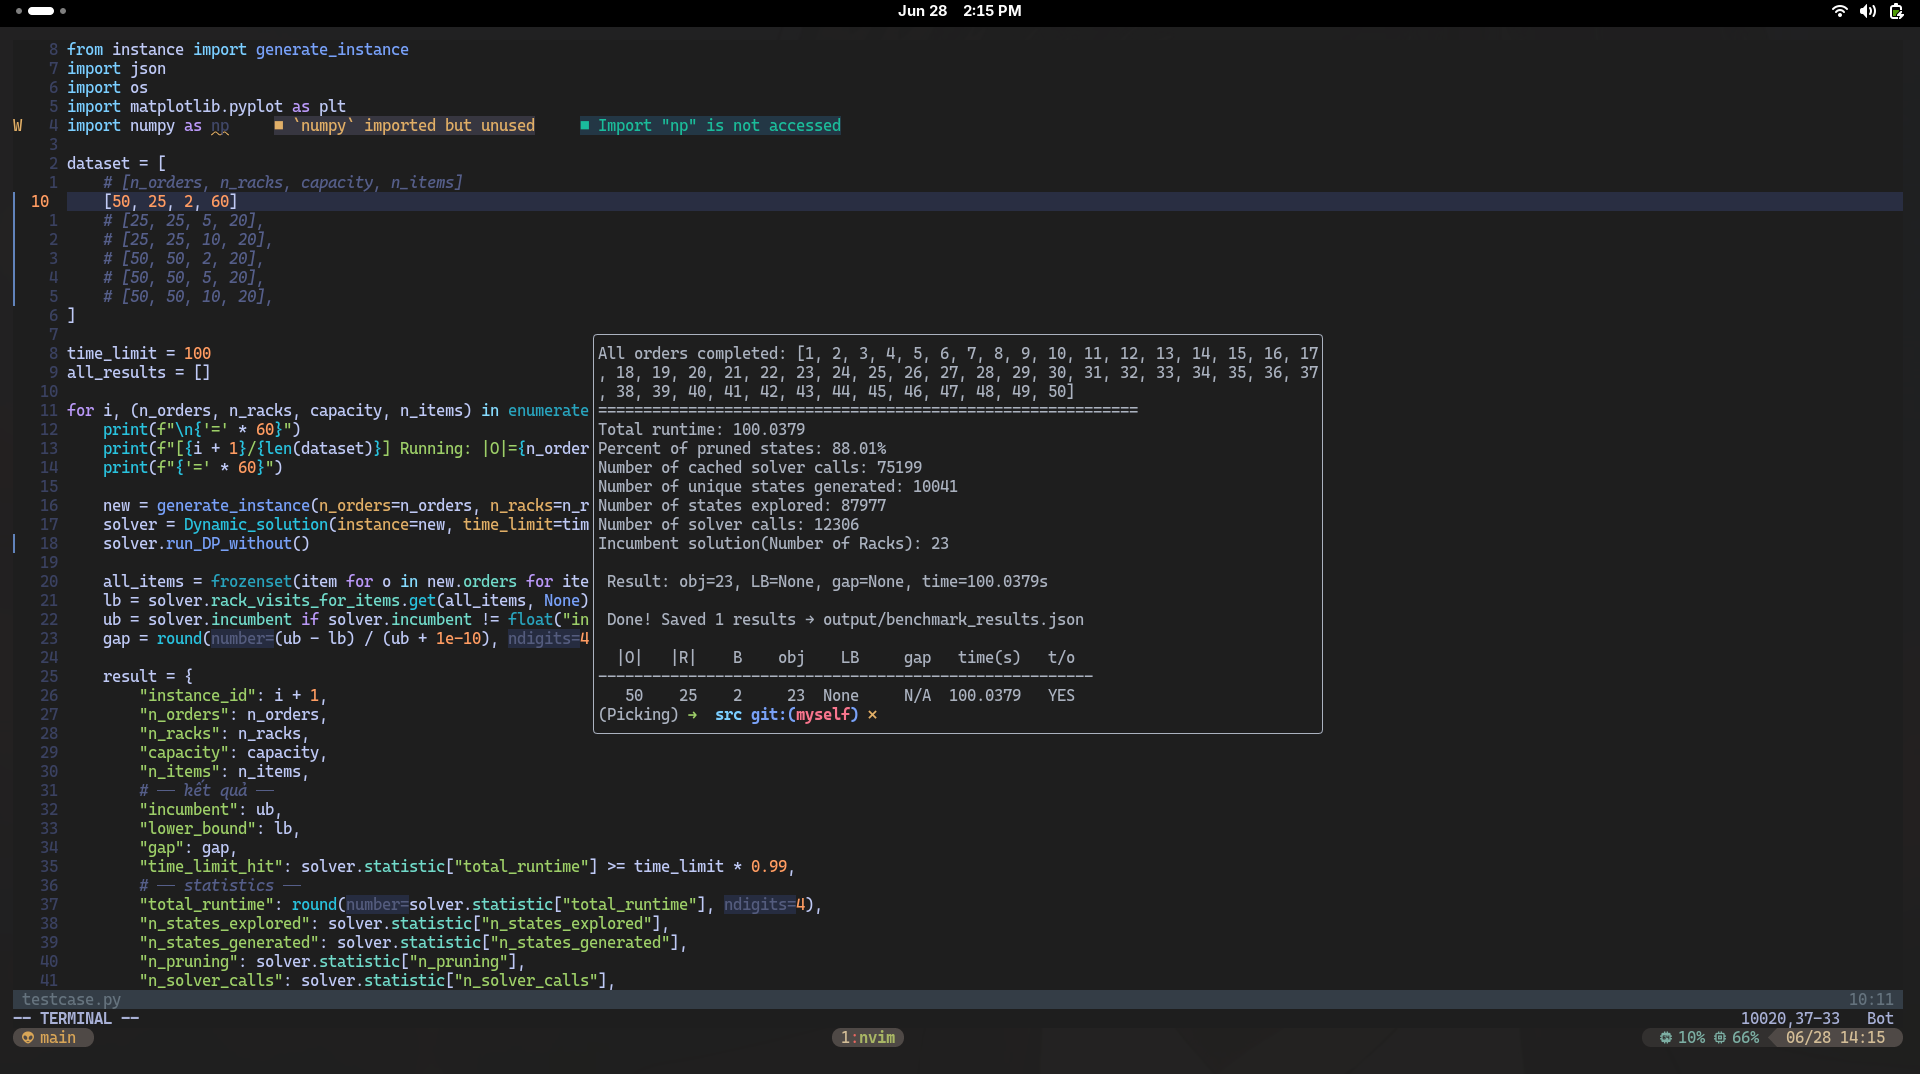

In [2]:
from DYSOLUTION import Dynamic_solution
from instance import generate_instance

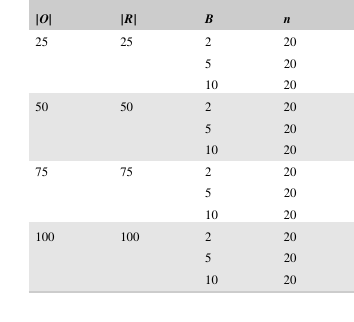

In [ ]:

dataset = [
    # [n_orders, n_racks, capacity, n_items]
    (25, 25, 2, 20),
    (25, 25, 5, 20),
    (25, 25, 10, 20),
    
    (50, 50, 2, 20),
    (50, 50, 5, 20),
    (50, 50, 10, 20),

    (75, 75, 2, 20),
    (75, 75, 5, 20),
    (75, 75, 10, 20),

    (100, 100, 2, 20),
    (100, 100, 5, 20),
    (100, 100, 10, 20)

]

In [ ]:
dataset1 = dataset[:4]  # First 4 instances
sample1 = "results/sample1"
print(dataset1)
